### Import the Libraries

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
data = pd.read_csv("./Data/weekly_aggregated_data.csv")

In [64]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Average ETH Price (USD)           242 non-null    float64
 1   Stablecoin Fee Share (%)          242 non-null    float64
 2   Stablecoin Sequencer Fees (ETH)   242 non-null    float64
 3   Stablecoin Sequencer Fees (USD)   242 non-null    float64
 4   Stablecoin Supply (USD)           242 non-null    float64
 5   Stablecoin Transfer Volume (USD)  242 non-null    float64
 6   Stablecoin Transfers              242 non-null    int64  
 7   Stablecoin Velocity               242 non-null    float64
 8   Total Sequencer Fees (ETH)        242 non-null    float64
 9   Total Sequencer Fees (USD)        242 non-null    float64
 10  Total Transactions                242 non-null    int64  
 11  Unique Senders                    242 non-null    int64  
 12  Week               

In [65]:
data.head()

,Average ETH Price (USD),Stablecoin Fee Share (%),Stablecoin Sequencer Fees (ETH),Stablecoin Sequencer Fees (USD),Stablecoin Supply (USD),Stablecoin Transfer Volume (USD),Stablecoin Transfers,Stablecoin Velocity,Total Sequencer Fees (ETH),Total Sequencer Fees (USD),Total Transactions,Unique Senders,Week
0,2334.244380,0.492543,17.987250,41933.45426,4.044240e+09,1.334658e+10,7059225,3.300144,36.493424,85136.57000,12999803,448924,13-04-2026 00:00
1,2193.737981,0.510228,19.849181,43442.61621,3.869507e+09,1.526954e+10,7983886,3.946119,38.921682,85143.47948,15790545,755219,06-04-2026 00:00
2,2065.759350,0.519574,18.141462,37518.82211,3.813087e+09,1.482269e+10,7713879,3.887319,34.918043,72210.77391,13210757,618259,30-03-2026 00:00
3,2076.655992,0.438195,19.999321,41642.30515,3.802491e+09,1.251822e+10,7850761,3.292110,45.618868,95031.39700,16827183,453240,23-03-2026 00:00
4,2200.757262,0.474810,20.062416,44427.08996,3.816785e+09,1.404861e+10,8465060,3.680746,42.409328,93568.19507,15798555,469363,16-03-2026 00:00


In [66]:
data.columns

Index(['Average ETH Price (USD)', 'Stablecoin Fee Share (%)',
       'Stablecoin Sequencer Fees (ETH)', 'Stablecoin Sequencer Fees (USD)',
       'Stablecoin Supply (USD)', 'Stablecoin Transfer Volume (USD)',
       'Stablecoin Transfers', 'Stablecoin Velocity',
       'Total Sequencer Fees (ETH)', 'Total Sequencer Fees (USD)',
       'Total Transactions', 'Unique Senders', 'Week'],
      dtype='str')

In [67]:
cols = [
    'Average ETH Price (USD)', 
    'Stablecoin Supply (USD)', 
    'Stablecoin Velocity', 
    'Stablecoin Transfer Volume (USD)', 
    'Stablecoin Transfers',
    'Stablecoin Sequencer Fees (ETH)',
    'Stablecoin Sequencer Fees (USD)',
    'Total Sequencer Fees (ETH)',
    'Total Sequencer Fees (USD)'
]

In [68]:
corr_matrix = data[cols].corr().round(2)

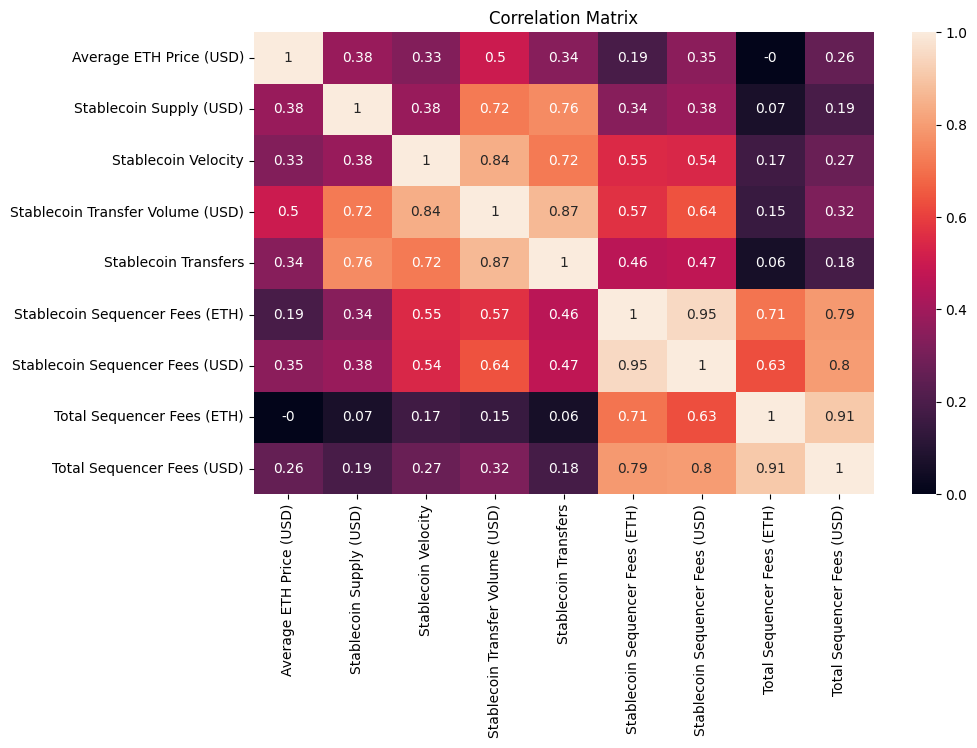

In [69]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [70]:
data.columns

Index(['Average ETH Price (USD)', 'Stablecoin Fee Share (%)',
       'Stablecoin Sequencer Fees (ETH)', 'Stablecoin Sequencer Fees (USD)',
       'Stablecoin Supply (USD)', 'Stablecoin Transfer Volume (USD)',
       'Stablecoin Transfers', 'Stablecoin Velocity',
       'Total Sequencer Fees (ETH)', 'Total Sequencer Fees (USD)',
       'Total Transactions', 'Unique Senders', 'Week'],
      dtype='str')

### Pearson and Spearman Rank Correlation

In [71]:
data["log_supply"] = np.log(data["Stablecoin Supply (USD)"])
data["log_total_fees_eth"] = np.log(data["Total Sequencer Fees (ETH)"])
data['log_stablecoin_fees_eth'] = np.log(data["Stablecoin Sequencer Fees (ETH)"])

In [72]:
pairs_1 = [
    ("Stablecoin Sequencer Fees (ETH)", "Total Sequencer Fees (ETH)"),
    ("Stablecoin Sequencer Fees (USD)", "Total Sequencer Fees (USD)"),
    ("Stablecoin Supply (USD)", "Stablecoin Sequencer Fees (ETH)"),
    ("Stablecoin Supply (USD)", "Stablecoin Sequencer Fees (USD)"),
    ("Stablecoin Velocity", "Total Sequencer Fees (ETH)"),
    ("Stablecoin Velocity", "Total Sequencer Fees (USD)"),
    ("Stablecoin Transfer Volume (USD)", "Total Sequencer Fees (ETH)"),
    ("Stablecoin Transfer Volume (USD)", "Total Sequencer Fees (USD)"),
    ("Stablecoin Supply (USD)", "Total Sequencer Fees (ETH)"),
    ("Stablecoin Supply (USD)", "Total Sequencer Fees (USD)"),
    ("Stablecoin Transfers", "Total Sequencer Fees (ETH)"),
    ("Stablecoin Transfers", "Total Sequencer Fees (USD)"),
    ('log_supply', 'log_total_fees_eth')
]

In [73]:
def interpret_strength(r):
    r_abs = abs(r)
    if r_abs > 0.7:
        return "Very Strong"
    elif r_abs >= 0.4:
        return "Strong"
    elif r_abs >= 0.2:
        return "Moderate"
    else:
        return "Weak"

In [74]:
pearson_results = []
spearman_results = []

for x, y in pairs_1:
    df_temp = data[[x, y]].dropna()

    # Pearson
    r, p = pearsonr(df_temp[x], df_temp[y])
    pearson_results.append({
        "X": x,
        "Y": y,
        "Pearson_r": round(r, 2),
        "p_value": round(p, 4),
        "Strength": interpret_strength(r)
    })

    # Spearman
    rho, p_s = spearmanr(df_temp[x], df_temp[y])
    spearman_results.append({
        "X": x,
        "Y": y,
        "Spearman_rho": round(rho, 2),
        "p_value": round(p_s, 4),
        "Strength": interpret_strength(rho)
    })

pearson_df = pd.DataFrame(pearson_results)
spearman_df = pd.DataFrame(spearman_results)

In [75]:
pearson_df

,X,Y,Pearson_r,p_value,Strength
0,Stablecoin Sequencer Fees (ETH),Total Sequencer Fees (ETH),0.71,0.0000,Very Strong
1,Stablecoin Sequencer Fees (USD),Total Sequencer Fees (USD),0.80,0.0000,Very Strong
2,Stablecoin Supply (USD),Stablecoin Sequencer Fees (ETH),0.34,0.0000,Moderate
3,Stablecoin Supply (USD),Stablecoin Sequencer Fees (USD),0.38,0.0000,Moderate
4,Stablecoin Velocity,Total Sequencer Fees (ETH),0.17,0.0076,Weak
5,Stablecoin Velocity,Total Sequencer Fees (USD),0.27,0.0000,Moderate
6,Stablecoin Transfer Volume (USD),Total Sequencer Fees (ETH),0.15,0.0177,Weak
7,Stablecoin Transfer Volume (USD),Total Sequencer Fees (USD),0.32,0.0000,Moderate
8,Stablecoin Supply (USD),Total Sequencer Fees (ETH),0.07,0.2558,Weak
9,Stablecoin Supply (USD),Total Sequencer Fees (USD),0.19,0.0027,Weak


In [76]:
spearman_df

,X,Y,Spearman_rho,p_value,Strength
0,Stablecoin Sequencer Fees (ETH),Total Sequencer Fees (ETH),0.76,0.0000,Very Strong
1,Stablecoin Sequencer Fees (USD),Total Sequencer Fees (USD),0.77,0.0000,Very Strong
2,Stablecoin Supply (USD),Stablecoin Sequencer Fees (ETH),0.61,0.0000,Strong
3,Stablecoin Supply (USD),Stablecoin Sequencer Fees (USD),0.66,0.0000,Strong
4,Stablecoin Velocity,Total Sequencer Fees (ETH),0.37,0.0000,Moderate
5,Stablecoin Velocity,Total Sequencer Fees (USD),0.48,0.0000,Strong
6,Stablecoin Transfer Volume (USD),Total Sequencer Fees (ETH),0.30,0.0000,Moderate
7,Stablecoin Transfer Volume (USD),Total Sequencer Fees (USD),0.44,0.0000,Strong
8,Stablecoin Supply (USD),Total Sequencer Fees (ETH),0.14,0.0257,Weak
9,Stablecoin Supply (USD),Total Sequencer Fees (USD),0.25,0.0001,Moderate


### Log-Log Correlation

In [77]:
log_df = data[[
    'Stablecoin Supply (USD)', 
    'Stablecoin Velocity',
    'Stablecoin Transfer Volume (USD)', 
    'Stablecoin Transfers',
    'Total Transactions', 
    'Stablecoin Sequencer Fees (ETH)',
    'Total Sequencer Fees (ETH)',
    'Stablecoin Sequencer Fees (USD)',
    'Total Sequencer Fees (USD)'
]]

log_df = log_df[(log_df > 0).all(axis=1)]

log_df["log_supply"] = np.log(log_df["Stablecoin Supply (USD)"])
log_df['log_velocity'] = np.log(log_df["Stablecoin Velocity"])
log_df["log_volume"] = np.log(log_df["Stablecoin Transfer Volume (USD)"])
log_df['log_transfers'] = np.log(log_df["Stablecoin Transfers"])
log_df["log_tx_count"] = np.log(log_df["Total Transactions"])
log_df["log_stablecoin_fees_eth"] = np.log(log_df["Stablecoin Sequencer Fees (ETH)"])
log_df["log_total_fees_eth"] = np.log(log_df["Total Sequencer Fees (ETH)"])
log_df["log_stablecoin_fees_usd"] = np.log(log_df["Stablecoin Sequencer Fees (USD)"])
log_df["log_total_fees_usd"] = np.log(log_df["Total Sequencer Fees (USD)"])

In [78]:
x_vars = ["log_supply", "log_velocity", "log_volume", "log_transfers", "log_tx_count"]

y_vars = [
    "log_total_fees_eth",
    "log_stablecoin_fees_eth",
    "log_total_fees_usd",
    "log_stablecoin_fees_usd"
]

results = []

for x in x_vars:
    for y in y_vars:
        df_temp = log_df[[x, y]].dropna()

        r, p = pearsonr(df_temp[x], df_temp[y])

        results.append({
            "X": x,
            "Y": y,
            "Pearson_r": round(r, 2),
            "p_value": round(p, 4)
        })

log_corr_df = pd.DataFrame(results)

In [79]:
log_corr_df["Strength"] = log_corr_df["Pearson_r"].apply(interpret_strength)
log_corr_df["Significant (p < 0.001)"] = log_corr_df["p_value"] < 0.001

In [80]:
log_corr_df

,X,Y,Pearson_r,p_value,Strength,Significant (p < 0.001)
0,log_supply,log_total_fees_eth,0.14,0.0354,Weak,False
1,log_supply,log_stablecoin_fees_eth,0.57,0.0000,Strong,True
2,log_supply,log_total_fees_usd,0.22,0.0007,Moderate,True
3,log_supply,log_stablecoin_fees_usd,0.57,0.0000,Strong,True
4,log_velocity,log_total_fees_eth,0.37,0.0000,Moderate,True
5,log_velocity,log_stablecoin_fees_eth,0.77,0.0000,Very Strong,True
6,log_velocity,log_total_fees_usd,0.52,0.0000,Strong,True
7,log_velocity,log_stablecoin_fees_usd,0.82,0.0000,Very Strong,True
8,log_volume,log_total_fees_eth,0.32,0.0000,Moderate,True
9,log_volume,log_stablecoin_fees_eth,0.79,0.0000,Very Strong,True


### Period-Based Analysis 

In [81]:
data = pd.read_csv("./Data/weekly_aggregated_data.csv")

In [82]:
data['Week'] = pd.to_datetime(data['Week'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\3129392324.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Week'] = pd.to_datetime(data['Week'])


In [83]:
print(data['Week'].min())
print(data['Week'].max())

2021-08-30 00:00:00
2026-04-13 00:00:00


In [84]:
df_1 = data[
    (data['Week'] >= '2021-01-01') &
    (data['Week'] <= '2023-12-31')
]

df_2 = data[
    (data['Week'] >= '2024-01-01') &
    (data['Week'] <= '2026-12-31')
]

In [85]:
def compute_correlations(df, pairs):
    results = []

    for x, y, label in pairs:
        df_temp = df[[x, y]].dropna()

        pearson_r, pearson_p = pearsonr(df_temp[x], df_temp[y])
        spearman_r, spearman_p = spearmanr(df_temp[x], df_temp[y])

        results.append({
            "Variable Pair": label,
            "Pearson_r": round(pearson_r, 2),
            "Pearson_p": round(pearson_p, 4),
            "Spearman_rho": round(spearman_r, 2),
            "Spearman_p": round(spearman_p, 4)
        })

    return pd.DataFrame(results)

In [86]:
pairs = [
    ("Stablecoin Supply (USD)", "Total Sequencer Fees (ETH)", "Supply vs Total Fees (ETH)"),
    ("Stablecoin Velocity", "Total Sequencer Fees (ETH)", "Velocity vs Total Fees (ETH)"),
    ("Stablecoin Transfer Volume (USD)", "Total Sequencer Fees (ETH)", "Volume vs Total Fees (ETH)"),
    ("Total Transactions", "Total Sequencer Fees (ETH)", "Tx Count vs Total Fees (ETH)")
]

In [87]:
df_1_results = compute_correlations(df_1, pairs)
df_2_results = compute_correlations(df_2, pairs)

#### Growth Phase

In [88]:
df_1_results

,Variable Pair,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Supply vs Total Fees (ETH),0.43,0.0000,0.59,0.0
1,Velocity vs Total Fees (ETH),0.28,0.0019,0.69,0.0
2,Volume vs Total Fees (ETH),0.36,0.0000,0.76,0.0
3,Tx Count vs Total Fees (ETH),0.60,0.0000,0.71,0.0


#### Mature Phase

In [89]:
df_2_results

,Variable Pair,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Supply vs Total Fees (ETH),-0.09,0.3154,-0.26,0.0048
1,Velocity vs Total Fees (ETH),0.18,0.0464,0.40,0.0000
2,Volume vs Total Fees (ETH),0.18,0.0433,0.27,0.0031
3,Tx Count vs Total Fees (ETH),0.08,0.4051,0.24,0.0097


In [90]:
pairs = [
    ("Stablecoin Supply (USD)", "Stablecoin Sequencer Fees (ETH)", "Supply vs Stablecoin Fees (ETH)"),
    ("Stablecoin Velocity", "Stablecoin Sequencer Fees (ETH)", "Velocity vs Stablecoin Fees (ETH)"),
    ("Stablecoin Transfer Volume (USD)", "Stablecoin Sequencer Fees (ETH)", "Volume vs Stablecoin Fees (ETH)"),
    ("Total Transactions", "Stablecoin Sequencer Fees (ETH)", "Tx Count vs Stablecoin Fees (ETH)")
]

In [91]:
df_1_results = compute_correlations(df_1, pairs)
df_2_results = compute_correlations(df_2, pairs)

#### Growth Phase

In [92]:
df_1_results

,Variable Pair,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Supply vs Stablecoin Fees (ETH),0.66,0.0,0.68,0.0
1,Velocity vs Stablecoin Fees (ETH),0.55,0.0,0.73,0.0
2,Volume vs Stablecoin Fees (ETH),0.70,0.0,0.85,0.0
3,Tx Count vs Stablecoin Fees (ETH),0.76,0.0,0.76,0.0


#### Mature Phase

In [93]:
df_2_results

,Variable Pair,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Supply vs Stablecoin Fees (ETH),-0.11,0.2465,-0.25,0.0055
1,Velocity vs Stablecoin Fees (ETH),0.37,0.0000,0.53,0.0000
2,Volume vs Stablecoin Fees (ETH),0.41,0.0000,0.44,0.0000
3,Tx Count vs Stablecoin Fees (ETH),0.18,0.0489,0.32,0.0003


### Linear Regression (OLS)

In [94]:
df = pd.read_csv("./Data/weekly_aggregated_data.csv")

In [95]:
def run_regression(df, y_var, x_vars):
    df_temp = df[[y_var] + x_vars].dropna()

    X = df_temp[x_vars]
    y = df_temp[y_var]

    # Add constant (intercept)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    return {
        "R_squared": model.rsquared,
        "Adj_R_squared": model.rsquared_adj,
        "Coefficients": model.params,
        "P_values": model.pvalues,
        "Model_Summary": model.summary()
    }

In [96]:
# Model 1 (ETH)
model1 = run_regression(
    data,
    y_var="Total Sequencer Fees (ETH)",
    x_vars=["Stablecoin Supply (USD)", "Stablecoin Velocity"]
)

In [97]:
# Model 2 (USD)
model2 = run_regression(
    df,
    y_var="Total Sequencer Fees (USD)",
    x_vars=["Stablecoin Supply (USD)", 
            "Stablecoin Velocity", 
            "Average ETH Price (USD)"]
)

In [98]:
# Model 3 (ETH + Tx Count)
model3 = run_regression(
    df,
    y_var="Total Sequencer Fees (ETH)",
    x_vars=["Stablecoin Supply (USD)", 
            "Stablecoin Velocity", 
            "Total Transactions"]
)

In [99]:
def extract_results(model_dict, model_name):
    return pd.DataFrame({
        "Model": model_name,
        "Variable": model_dict["Coefficients"].index,
        "Coefficient": model_dict["Coefficients"].values,
        "P_value": model_dict["P_values"].values
    })

results_df = pd.concat([
    extract_results(model1, "Model 1 (ETH)"),
    extract_results(model2, "Model 2 (USD)"),
    extract_results(model3, "Model 3 (ETH + Tx)")
])

In [100]:
print("Model 1 R²:", model1["R_squared"])
print("Model 2 R²:", model2["R_squared"])
print("Model 3 R²:", model3["R_squared"])

Model 1 R²: 0.029376678308561055
Model 2 R²: 0.10757989706317883
Model 3 R²: 0.06001924823424898


In [101]:
results_df

,Model,Variable,Coefficient,P_value
0,Model 1 (ETH),const,7.817404e+01,8.202968e-07
1,Model 1 (ETH),Stablecoin Supply (USD),9.136576e-10,8.810313e-01
2,Model 1 (ETH),Stablecoin Velocity,6.413184e+00,1.579575e-02
0,Model 2 (USD),const,-1.155844e+04,8.570689e-01
1,Model 2 (USD),Stablecoin Supply (USD),1.346256e-05,4.419664e-01
2,Model 2 (USD),Stablecoin Velocity,2.081566e+04,5.419640e-03
3,Model 2 (USD),Average ETH Price (USD),6.648864e+01,9.323394e-03
0,Model 3 (ETH + Tx),const,9.446615e+01,2.183288e-08
1,Model 3 (ETH + Tx),Stablecoin Supply (USD),-2.446615e-08,2.594663e-02
2,Model 3 (ETH + Tx),Stablecoin Velocity,-2.015930e+00,6.139189e-01


### Linear Regression (using Sklearn)

===== Model Performance =====
MAE  : 88.2851
RMSE : 100.7759
R²   : -0.5688

===== Model Coefficients =====
                   Feature   Coefficient
0  Stablecoin Supply (USD)  5.910592e-09
1      Stablecoin Velocity  1.000519e+01
Intercept: 69.11283813345271

===== Sample Predictions =====
          Week  Total Sequencer Fees (ETH)   Predicted       Error
193 2025-05-12                   91.323521  212.069786 -120.746266
194 2025-05-19                   94.429657  238.540784 -144.111127
195 2025-05-26                   74.816022  174.434140  -99.618118
196 2025-06-02                   53.261092  148.277490  -95.016398
197 2025-06-09                   73.669671  174.084074 -100.414403


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1886219354.py:9: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


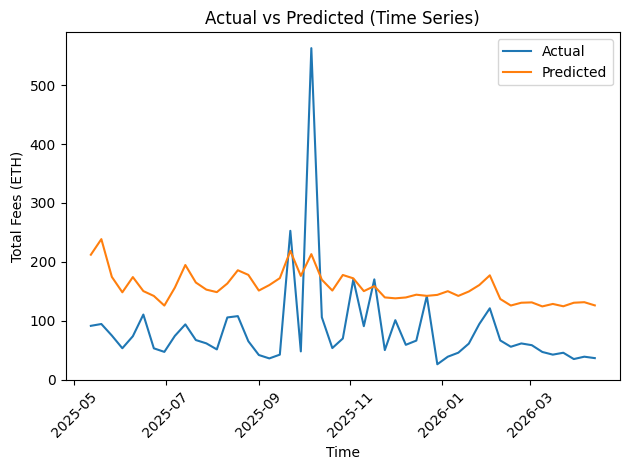

In [102]:
df = pd.read_csv("./Data/weekly_aggregated_data.csv")

# 2. Define Features & Target
features = ["Stablecoin Supply (USD)", "Stablecoin Velocity"]
target = "Total Sequencer Fees (ETH)"


# 3. Prepare Data
df['Week'] = pd.to_datetime(df['Week'])

# Keep only required columns + Week
df_model = df[["Week"] + features + [target]].dropna()

# Sort by time
df_model = df_model.sort_values(by="Week").reset_index(drop=True)


# 4. Train-Test Split (Time-Based)
split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index]
test_df = df_model.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]


# 5. Train Model
model = LinearRegression()
model.fit(X_train, y_train)


# 6. Predictions
y_pred = model.predict(X_test)


# 7. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Model Performance =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 8. Coefficients
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print("\n===== Model Coefficients =====")
print(coeff_df)
print("Intercept:", model.intercept_)


# 9. Actual vs Predicted Table
results_df = test_df.copy()
results_df["Predicted"] = y_pred
results_df["Error"] = results_df[target] - results_df["Predicted"]

print("\n===== Sample Predictions =====")
print(results_df[["Week", target, "Predicted", "Error"]].head())


# 10. Plot: Actual vs Predicted (Time Series)
plt.figure()
plt.plot(results_df["Week"], results_df[target], label="Actual")
plt.plot(results_df["Week"], results_df["Predicted"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("Total Fees (ETH)")
plt.title("Actual vs Predicted (Time Series)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


===== Model Performance =====
MAE  : 257874.0276
RMSE : 341486.5766
R²   : 0.0196

===== Model Coefficients =====
                   Feature   Coefficient
0  Stablecoin Supply (USD)      0.000027
1      Stablecoin Velocity  25853.834313
2  Average ETH Price (USD)     64.354585
Intercept: -20485.806350615865

===== Sample Predictions =====
          Week  Total Sequencer Fees (USD)      Predicted          Error
193 2025-05-12                 231765.6751  528930.042661 -297164.367561
194 2025-05-19                 241429.7816  596098.598606 -354668.817006
195 2025-05-26                 195033.8126  438650.191606 -243616.379006
196 2025-06-02                 136435.2458  371017.607011 -234582.361211
197 2025-06-09                 193218.9300  444187.602756 -250968.672756


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\2844899199.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


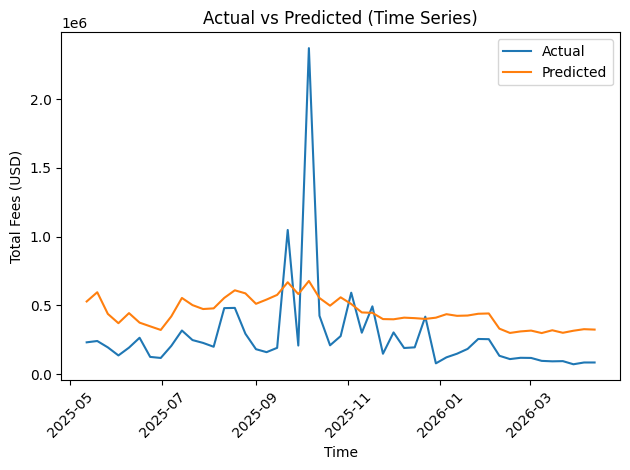

In [103]:
df = pd.read_csv("./Data/weekly_aggregated_data.csv")

# 2. Define Features & Target
features = ["Stablecoin Supply (USD)", 
            "Stablecoin Velocity", 
            "Average ETH Price (USD)"]

target = "Total Sequencer Fees (USD)"


# 3. Prepare Data
df['Week'] = pd.to_datetime(df['Week'])

# Keep only required columns + Week
df_model = df[["Week"] + features + [target]].dropna()

# Sort by time
df_model = df_model.sort_values(by="Week").reset_index(drop=True)


# 4. Train-Test Split (Time-Based)
split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index]
test_df = df_model.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]


# 5. Train Model
model = LinearRegression()
model.fit(X_train, y_train)


# 6. Predictions
y_pred = model.predict(X_test)


# 7. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Model Performance =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 8. Coefficients
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print("\n===== Model Coefficients =====")
print(coeff_df)
print("Intercept:", model.intercept_)


# 9. Actual vs Predicted Table
results_df = test_df.copy()
results_df["Predicted"] = y_pred
results_df["Error"] = results_df[target] - results_df["Predicted"]

print("\n===== Sample Predictions =====")
print(results_df[["Week", target, "Predicted", "Error"]].head())


# 10. Plot: Actual vs Predicted (Time Series)
plt.figure()
plt.plot(results_df["Week"], results_df[target], label="Actual")
plt.plot(results_df["Week"], results_df["Predicted"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("Total Fees (USD)")
plt.title("Actual vs Predicted (Time Series)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


===== Model Performance =====
MAE  : 160.4653
RMSE : 190.5484
R²   : -4.6087

===== Model Coefficients =====
                   Feature   Coefficient
0  Stablecoin Supply (USD) -6.898621e-08
1      Stablecoin Velocity -1.566560e+01
2       Total Transactions  2.233243e-05
Intercept: 107.7410532183425

===== Sample Predictions =====
          Week  Total Sequencer Fees (ETH)   Predicted       Error
193 2025-05-12                   91.323521  213.115735 -121.792214
194 2025-05-19                   94.429657  172.688961  -78.259305
195 2025-05-26                   74.816022  220.069808 -145.253786
196 2025-06-02                   53.261092  217.269671 -164.008579
197 2025-06-09                   73.669671  211.275263 -137.605592


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\3756366527.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


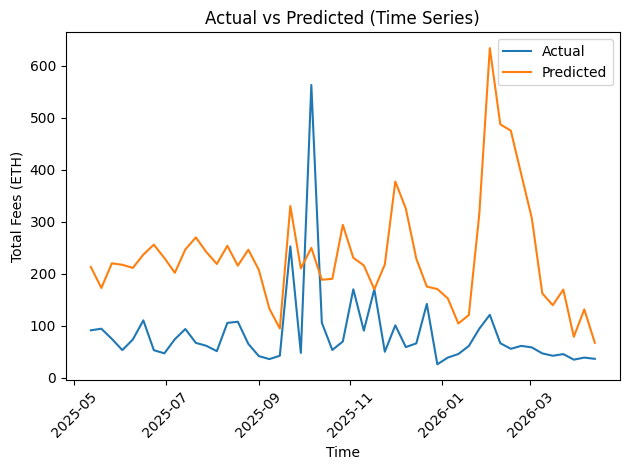

In [104]:
df = pd.read_csv("./Data/weekly_aggregated_data.csv")

# 2. Define Features & Target 
features = ["Stablecoin Supply (USD)", 
            "Stablecoin Velocity", 
            "Total Transactions"]

target = "Total Sequencer Fees (ETH)"


# 3. Prepare Data
df['Week'] = pd.to_datetime(df['Week'])

# Keep only required columns + Week
df_model = df[["Week"] + features + [target]].dropna()

# Sort by time
df_model = df_model.sort_values(by="Week").reset_index(drop=True)


# 4. Train-Test Split (Time-Based)
split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index]
test_df = df_model.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]


# 5. Train Model
model = LinearRegression()
model.fit(X_train, y_train)


# 6. Predictions
y_pred = model.predict(X_test)


# 7. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Model Performance =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 8. Coefficients
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print("\n===== Model Coefficients =====")
print(coeff_df)
print("Intercept:", model.intercept_)


# 9. Actual vs Predicted Table
results_df = test_df.copy()
results_df["Predicted"] = y_pred
results_df["Error"] = results_df[target] - results_df["Predicted"]

print("\n===== Sample Predictions =====")
print(results_df[["Week", target, "Predicted", "Error"]].head())


# 10. Plot: Actual vs Predicted (Time Series)
plt.figure()
plt.plot(results_df["Week"], results_df[target], label="Actual")
plt.plot(results_df["Week"], results_df["Predicted"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("Total Fees (ETH)")
plt.title("Actual vs Predicted (Time Series)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Stress Testing

In [105]:
data = pd.read_csv("./Data/weekly_aggregated_data.csv")

data['Week'] = pd.to_datetime(data['Week'])
data = data.sort_values(by='Week')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\3094492170.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Week'] = pd.to_datetime(data['Week'])


In [106]:
df_last_12 = data.tail(12)
df_last_12

,Average ETH Price (USD),Stablecoin Fee Share (%),Stablecoin Sequencer Fees (ETH),Stablecoin Sequencer Fees (USD),Stablecoin Supply (USD),Stablecoin Transfer Volume (USD),Stablecoin Transfers,Stablecoin Velocity,Total Sequencer Fees (ETH),Total Sequencer Fees (USD),Total Transactions,Unique Senders,Week
11,2777.730541,0.477901,44.751042,122416.01770,3.803382e+09,2.623627e+10,16706706,6.898144,94.432289,256153.71500,25875672,1122923,2026-01-26
10,2136.049385,0.421390,50.911939,107341.89200,3.883982e+09,3.300055e+10,15854523,8.496576,121.104391,254732.84790,41508030,1279966,2026-02-02
9,2017.673700,0.360526,23.988422,48316.38845,3.994674e+09,1.760669e+10,10290913,4.407541,66.480297,134016.50440,32420916,703257,2026-02-09
8,1970.058606,0.331660,18.507487,36457.22434,4.009590e+09,1.322707e+10,8226298,3.298858,55.798218,109923.46280,31149631,409109,2026-02-16
7,1945.047822,0.431323,26.447444,51448.45654,4.052146e+09,1.518168e+10,11308531,3.746578,61.423536,119280.67240,27818365,514728,2026-02-23
6,2014.848780,0.454685,26.616005,53761.32586,4.043662e+09,1.540620e+10,11127361,3.809962,58.464761,118238.56660,24083519,511372,2026-03-02
5,2064.419311,0.478875,22.525147,46404.35249,3.749622e+09,1.238094e+10,9406926,3.301916,46.962854,96902.93474,16339003,488120,2026-03-09
4,2200.757262,0.474810,20.062416,44427.08996,3.816785e+09,1.404861e+10,8465060,3.680746,42.409328,93568.19507,15798555,469363,2026-03-16
3,2076.655992,0.438195,19.999321,41642.30515,3.802491e+09,1.251822e+10,7850761,3.292110,45.618868,95031.39700,16827183,453240,2026-03-23
2,2065.759350,0.519574,18.141462,37518.82211,3.813087e+09,1.482269e+10,7713879,3.887319,34.918043,72210.77391,13210757,618259,2026-03-30


### Stress Test (USDC exists)

In [107]:
data2 = pd.read_csv("./Data/weekly_aggregated_data_excluding_usdc.csv")

data2['Week'] = pd.to_datetime(data2['Week'])
data2 = data2.sort_values(by='Week')

data2['Stablecoin Fee Share (%)'] = data2['Stablecoin Fee Share (%)'] * 100
data2['Stablecoin Fee Share (%)'] = round(data2['Stablecoin Fee Share (%)'], 2)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1721299311.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data2['Week'] = pd.to_datetime(data2['Week'])


In [108]:
df_last_12 = data2.tail(12)
df_last_12

,Average ETH Price (USD),Stablecoin Fee Share (%),Stablecoin Sequencer Fees (ETH),Stablecoin Sequencer Fees (USD),Stablecoin Supply (USD),Stablecoin Transfer Volume (USD),Stablecoin Transfers,Stablecoin Velocity,Total Sequencer Fees (ETH),Total Sequencer Fees (USD),Total Transactions,Unique Senders,Week
11,2777.730541,13.66,12.810448,34992.633780,3.803382e+09,5.265801e+09,4048469,1.384505,94.432289,256153.71500,25875672,560352,2026-01-26
10,2136.049385,11.78,14.250552,29997.306170,3.883982e+09,8.117507e+09,3971437,2.089996,121.104391,254732.84790,41508030,673222,2026-02-02
9,2017.673700,9.06,6.029646,12147.512210,3.994674e+09,5.305458e+09,2190184,1.328133,66.480297,134016.50440,32420916,339273,2026-02-09
8,1970.058606,7.82,4.366476,8601.278167,4.009590e+09,3.917272e+09,1528710,0.976976,55.798218,109923.46280,31149631,147418,2026-02-16
7,1945.047822,9.91,6.074590,11815.283010,4.052146e+09,3.768133e+09,1985590,0.929911,61.423536,119280.67240,27818365,182098,2026-02-23
6,2014.848780,9.48,5.540837,11209.866650,4.043662e+09,4.054997e+09,1849079,1.002803,58.464761,118238.56660,24083519,177234,2026-03-02
5,2064.419311,9.45,4.443221,9156.883621,3.749622e+09,2.768458e+09,1462400,0.738330,46.962854,96902.93474,16339003,164114,2026-03-09
4,2200.757262,9.68,4.098847,9061.315383,3.816785e+09,3.397983e+09,1395272,0.890274,42.409328,93568.19507,15798555,158990,2026-03-16
3,2076.655992,9.30,4.246931,8838.840437,3.802491e+09,3.199118e+09,1505639,0.841322,45.618868,95031.39700,16827183,162566,2026-03-23
2,2065.759350,11.39,3.979646,8227.689805,3.813087e+09,3.009313e+09,1690973,0.789206,34.918043,72210.77391,13210757,241245,2026-03-30


### Stress Test (USDT exists)

In [109]:
data3 = pd.read_csv("./Data/weekly_aggregated_data_excluding_usdt.csv")

data3['Week'] = pd.to_datetime(data3['Week'])
data3 = data3.sort_values(by='Week')

data3['Stablecoin Fee Share (%)'] = data3['Stablecoin Fee Share (%)'] * 100
data3['Stablecoin Fee Share (%)'] = round(data3['Stablecoin Fee Share (%)'], 2)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\4243582780.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data3['Week'] = pd.to_datetime(data3['Week'])


In [110]:
df_last_12 = data3.tail(12)
df_last_12

,Average ETH Price (USD),Stablecoin Fee Share (%),Stablecoin Sequencer Fees (ETH),Stablecoin Sequencer Fees (USD),Stablecoin Supply (USD),Stablecoin Transfer Volume (USD),Stablecoin Transfers,Stablecoin Velocity,Total Sequencer Fees (ETH),Total Sequencer Fees (USD),Total Transactions,Unique Senders,Week
11,2777.730541,42.07,39.337495,107764.55350,3.803382e+09,2.129031e+10,12752594,5.597733,94.432289,256153.71500,25875672,613260,2026-01-26
10,2136.049385,35.90,43.376246,91461.67927,3.883982e+09,2.577465e+10,12026087,6.636140,121.104391,254732.84790,41508030,666073,2026-02-02
9,2017.673700,31.58,21.016358,42328.60406,3.994674e+09,1.360966e+10,8200619,3.406952,66.480297,134016.50440,32420916,397042,2026-02-09
8,1970.058606,29.56,16.494537,32492.29884,4.009590e+09,1.046745e+10,6755836,2.610604,55.798218,109923.46280,31149631,279295,2026-02-16
7,1945.047822,37.43,22.954496,44641.48072,4.052146e+09,1.205804e+10,9390657,2.975718,61.423536,119280.67240,27818365,353100,2026-02-23
6,2014.848780,40.17,23.518340,47500.76570,4.043662e+09,1.224492e+10,9355639,3.028175,58.464761,118238.56660,24083519,354653,2026-03-02
5,2064.419311,42.49,19.983916,41170.97203,3.749622e+09,1.002785e+10,7994980,2.674362,46.962854,96902.93474,16339003,342112,2026-03-09
4,2200.757262,41.75,17.630888,39061.45755,3.816785e+09,1.105385e+10,7123342,2.896115,42.409328,93568.19507,15798555,329127,2026-03-16
3,2076.655992,38.07,17.377285,36181.33389,3.802491e+09,9.570967e+09,6401135,2.517026,45.618868,95031.39700,16827183,308442,2026-03-23
2,2065.759350,44.50,15.536641,32133.45279,3.813087e+09,1.201927e+10,6068099,3.152110,34.918043,72210.77391,13210757,400607,2026-03-30


### Stress Test (USDC + USDT exists)

In [111]:
data4 = pd.read_csv("./Data/weekly_aggregated_data_excluding_usdc_and_usdt.csv")

data4['Week'] = pd.to_datetime(data4['Week'])
data4 = data4.sort_values(by='Week')

data4['Stablecoin Fee Share (%)'] = data4['Stablecoin Fee Share (%)'] * 100
data4['Stablecoin Fee Share (%)'] = round(data4['Stablecoin Fee Share (%)'], 2)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\2810681588.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data4['Week'] = pd.to_datetime(data4['Week'])


In [112]:
df_last_12 = data4.tail(12)
df_last_12

,Average ETH Price (USD),Stablecoin Fee Share (%),Stablecoin Sequencer Fees (ETH),Stablecoin Sequencer Fees (USD),Stablecoin Supply (USD),Stablecoin Transfer Volume (USD),Stablecoin Transfers,Stablecoin Velocity,Total Sequencer Fees (ETH),Total Sequencer Fees (USD),Total Transactions,Unique Senders,Week
11,2777.730541,0.79,0.760551,2034.652998,3.803382e+09,3.198415e+08,94357,0.084094,94.432289,256153.71500,25875672,11586,2026-01-26
10,2136.049385,1.03,1.250537,2625.298859,3.883982e+09,8.916058e+08,143001,0.229560,121.104391,254732.84790,41508030,16711,2026-02-02
9,2017.673700,0.64,0.426956,861.273125,3.994674e+09,1.308431e+09,99890,0.327544,66.480297,134016.50440,32420916,7182,2026-02-09
8,1970.058606,0.44,0.243195,478.764294,4.009590e+09,1.157657e+09,58248,0.288722,55.798218,109923.46280,31149631,4846,2026-02-16
7,1945.047822,0.49,0.300616,584.664384,4.052146e+09,6.444959e+08,67716,0.159051,61.423536,119280.67240,27818365,4949,2026-02-23
6,2014.848780,0.61,0.359600,726.988850,4.043662e+09,8.937143e+08,77357,0.221016,58.464761,118238.56660,24083519,5138,2026-03-02
5,2064.419311,0.49,0.230663,474.891166,3.749622e+09,4.153660e+08,50454,0.110775,46.962854,96902.93474,16339003,4212,2026-03-09
4,2200.757262,0.53,0.224878,496.495254,3.816785e+09,4.032172e+08,53554,0.105643,42.409328,93568.19507,15798555,4323,2026-03-16
3,2076.655992,0.63,0.288364,600.441811,3.802491e+09,2.518675e+08,56013,0.066238,45.618868,95031.39700,16827183,4021,2026-03-23
2,2065.759350,0.51,0.177598,366.979635,3.813087e+09,2.058962e+08,45193,0.053997,34.918043,72210.77391,13210757,5954,2026-03-30


### Stress Test (USDe exists)

In [113]:
data5 = pd.read_csv("./Data/weekly_aggregated_data_excluding_usde.csv")

data5['Week'] = pd.to_datetime(data5['Week'])
data5 = data5.sort_values(by='Week')

data5['Stablecoin Fee Share (%)'] = data5['Stablecoin Fee Share (%)'] * 100
data5['Stablecoin Fee Share (%)'] = round(data5['Stablecoin Fee Share (%)'], 2)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1160192354.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data5['Week'] = pd.to_datetime(data5['Week'])


In [114]:
df_last_12 = data5.tail(12)
df_last_12

,Average ETH Price (USD),Stablecoin Fee Share (%),Stablecoin Sequencer Fees (ETH),Stablecoin Sequencer Fees (USD),Stablecoin Supply (USD),Stablecoin Transfer Volume (USD),Stablecoin Transfers,Stablecoin Velocity,Total Sequencer Fees (ETH),Total Sequencer Fees (USD),Total Transactions,Unique Senders,Week
11,2777.730541,47.77,44.729917,122359.16740,3.803382e+09,2.619309e+10,16688088,6.886790,94.432289,256153.71500,25875672,1122173,2026-01-26
10,2136.049385,42.12,50.893532,107302.91300,3.883982e+09,3.295544e+10,15831489,8.484962,121.104391,254732.84790,41508030,1279201,2026-02-02
9,2017.673700,36.04,23.978397,48296.18738,3.994674e+09,1.758650e+10,10276886,4.402488,66.480297,134016.50440,32420916,702758,2026-02-09
8,1970.058606,33.16,18.501476,36445.37478,4.009590e+09,1.321493e+10,8217021,3.295831,55.798218,109923.46280,31149631,408742,2026-02-16
7,1945.047822,43.12,26.437993,51430.08729,4.052146e+09,1.516402e+10,11298159,3.742221,61.423536,119280.67240,27818365,514443,2026-02-23
6,2014.848780,45.46,26.608835,53746.83529,4.043662e+09,1.539633e+10,11117944,3.807521,58.464761,118238.56660,24083519,511120,2026-03-02
5,2064.419311,47.88,22.519774,46393.29766,3.749622e+09,1.237235e+10,9400867,3.299626,46.962854,96902.93474,16339003,487918,2026-03-09
4,2200.757262,47.47,20.056528,44414.04467,3.816785e+09,1.403329e+10,8457471,3.676731,42.409328,93568.19507,15798555,469131,2026-03-16
3,2076.655992,43.81,19.995770,41634.94661,3.802491e+09,1.250554e+10,7842890,3.288776,45.618868,95031.39700,16827183,453050,2026-03-23
2,2065.759350,51.95,18.138390,37512.48545,3.813087e+09,1.481549e+10,7708240,3.885431,34.918043,72210.77391,13210757,618104,2026-03-30


### Stress Test Model

In [115]:
def run_stress_test(data, dataset_name="Dataset"):

    # STEP 1: PREPROCESSING
    df = data.copy()

    df['Week'] = pd.to_datetime(df['Week'])
    df = df.sort_values(by='Week')

    df['Stablecoin Fee Share (%)'] = df['Stablecoin Fee Share (%)'] * 100
    df['Stablecoin Fee Share (%)'] = df['Stablecoin Fee Share (%)'].round(2)

    df_last_12 = df.tail(12)

    # BASELINE METRICS
    baseline_total_fees = df_last_12['Total Sequencer Fees (USD)'].mean()
    baseline_total_fees = round(baseline_total_fees, 2)

    baseline_stablecoin_fees = df_last_12['Stablecoin Sequencer Fees (USD)'].mean()
    baseline_stablecoin_fees = round(baseline_stablecoin_fees, 2)

    baseline_non_stablecoin_fees = baseline_total_fees - baseline_stablecoin_fees
    baseline_non_stablecoin_fees = round(baseline_non_stablecoin_fees, 2)

    stablecoin_fee_share = baseline_stablecoin_fees / baseline_total_fees

    annual_total_fees = baseline_total_fees * 52
    annual_stablecoin_fees = baseline_stablecoin_fees * 52

    print(f"\n===== BASELINE METRICS ({dataset_name}) =====")
    print(f"Weekly Total Fees: ${baseline_total_fees:,.2f}")
    print(f"Weekly Stablecoin Fees: ${baseline_stablecoin_fees:,.2f}")
    print(f"Weekly Non-Stablecoin Fees: ${baseline_non_stablecoin_fees:,.2f}")
    print(f"Stablecoin Fee Share: {stablecoin_fee_share:.2%}")
    print(f"Annual Total Fees: ${annual_total_fees:,.2f}")
    print(f"Annual Stablecoin Fees: ${annual_stablecoin_fees:,.2f}")

    # STEP 2: SCENARIOS
    scenarios = {
        "Mild (-20%)": 0.20,
        "Moderate (-40%)": 0.40,
        "Severe (-60%)": 0.60
    }

    # STEP 3: BUILD OUTPUT TABLE
    def format_usd(x):
        if x == "-" or x is None:
            return "-"
        return f"${x:,.0f}"

    rows = []

    # Baseline row
    rows.append({
        "Scenario": "Baseline",
        "Stablecoin Fees": format_usd(baseline_stablecoin_fees),
        "Total Fees": format_usd(baseline_total_fees),
        "Weekly Loss": "-",
        "% Decline": "-",
        "Annualized Loss": "-"
    })

    # Scenario rows
    for name, contraction in scenarios.items():

        projected_stable = baseline_stablecoin_fees * (1 - contraction)
        projected_total = projected_stable + baseline_non_stablecoin_fees

        weekly_loss = baseline_total_fees - projected_total
        weekly_loss = round(weekly_loss)

        pct_decline = (weekly_loss / baseline_total_fees) * 100
        annual_loss = weekly_loss * 52

        rows.append({
            "Scenario": name,
            "Stablecoin Fees": format_usd(projected_stable),
            "Total Fees": format_usd(projected_total),
            "Weekly Loss": format_usd(weekly_loss),
            "% Decline": f"{pct_decline:.1f}%",
            "Annualized Loss": format_usd(annual_loss)
        })

    output_df = pd.DataFrame(rows)

    # STEP 4: PRINT REPORT
    print("\n6.5 Worked Example (Using Actual Data)\n")

    print(
        f"Assume baseline weekly total fees = {format_usd(baseline_total_fees)}, "
        f"of which stablecoin fees = {format_usd(baseline_stablecoin_fees)} "
        f"({stablecoin_fee_share:.0%}) and non-stablecoin fees = {format_usd(baseline_non_stablecoin_fees)}.\n"
    )

    print(output_df.to_string(index=False))

    # STEP 5: INTERPRETATION
    print("\n")

    print(
        f"The pattern is clean and defensible: a 20% contraction in stablecoin activity causes a ~{stablecoin_fee_share*20:.1f}% drop in total fees, "
        f"a 40% contraction causes ~{stablecoin_fee_share*40:.1f}%, and a 60% contraction causes ~{stablecoin_fee_share*60:.1f}%. "
        f"This maps directly to the current ~{stablecoin_fee_share:.0%} fee share."
    )

    return output_df

#### Stress Model on Weekly Aggregated Data 

In [116]:
# Example datasets
data = pd.read_csv("./Data/weekly_aggregated_data.csv")

# Run stress test
output1 = run_stress_test(data, "Weekly Aggregated Data")
output1.to_csv("./Results/weekly_stablecoin_stress_test.csv", index=False)


===== BASELINE METRICS (Weekly Aggregated Data) =====
Weekly Total Fees: $126,694.93
Weekly Stablecoin Fees: $56,259.16
Weekly Non-Stablecoin Fees: $70,435.77
Stablecoin Fee Share: 44.41%
Annual Total Fees: $6,588,136.36
Annual Stablecoin Fees: $2,925,476.32

6.5 Worked Example (Using Actual Data)

Assume baseline weekly total fees = $126,695, of which stablecoin fees = $56,259 (44%) and non-stablecoin fees = $70,436.

       Scenario Stablecoin Fees Total Fees Weekly Loss % Decline Annualized Loss
       Baseline         $56,259   $126,695           -         -               -
    Mild (-20%)         $45,007   $115,443     $11,252      8.9%        $585,104
Moderate (-40%)         $33,755   $104,191     $22,504     17.8%      $1,170,208
  Severe (-60%)         $22,504    $92,939     $33,755     26.6%      $1,755,260


The pattern is clean and defensible: a 20% contraction in stablecoin activity causes a ~8.9% drop in total fees, a 40% contraction causes ~17.8%, and a 60% contraction c

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1243315993.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


#### Stress Model on Weekly Aggregated Data (without USDC)

In [117]:
# Example datasets
data_without_usdc = pd.read_csv("./Data/weekly_aggregated_data_excluding_usdc.csv")

# Run stress test
output2 = run_stress_test(data_without_usdc, "Weekly Aggregated Data without USDC")
output2.to_csv("./Results/weekly_stablecoin_stress_test_excluding_usdc.csv", index=False)


===== BASELINE METRICS (Weekly Aggregated Data without USDC) =====
Weekly Total Fees: $126,694.93
Weekly Stablecoin Fees: $13,538.41
Weekly Non-Stablecoin Fees: $113,156.52
Stablecoin Fee Share: 10.69%
Annual Total Fees: $6,588,136.36
Annual Stablecoin Fees: $703,997.32

6.5 Worked Example (Using Actual Data)

Assume baseline weekly total fees = $126,695, of which stablecoin fees = $13,538 (11%) and non-stablecoin fees = $113,157.

       Scenario Stablecoin Fees Total Fees Weekly Loss % Decline Annualized Loss
       Baseline         $13,538   $126,695           -         -               -
    Mild (-20%)         $10,831   $123,987      $2,708      2.1%        $140,816
Moderate (-40%)          $8,123   $121,280      $5,415      4.3%        $281,580
  Severe (-60%)          $5,415   $118,572      $8,123      6.4%        $422,396


The pattern is clean and defensible: a 20% contraction in stablecoin activity causes a ~2.1% drop in total fees, a 40% contraction causes ~4.3%, and a 60% c

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1243315993.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


#### Stress Model on Weekly Aggregated Data (without USDT)

In [118]:
# Example datasets
data_without_usdt = pd.read_csv("./Data/weekly_aggregated_data_excluding_usdt.csv")

# Run stress test
output3 = run_stress_test(data_without_usdt, "Weekly Aggregated Data without USDT")
output3.to_csv("./Results/weekly_stablecoin_stress_test_excluding_usdt.csv", index=False)


===== BASELINE METRICS (Weekly Aggregated Data without USDT) =====
Weekly Total Fees: $126,694.93
Weekly Stablecoin Fees: $48,971.81
Weekly Non-Stablecoin Fees: $77,723.12
Stablecoin Fee Share: 38.65%
Annual Total Fees: $6,588,136.36
Annual Stablecoin Fees: $2,546,534.12

6.5 Worked Example (Using Actual Data)

Assume baseline weekly total fees = $126,695, of which stablecoin fees = $48,972 (39%) and non-stablecoin fees = $77,723.

       Scenario Stablecoin Fees Total Fees Weekly Loss % Decline Annualized Loss
       Baseline         $48,972   $126,695           -         -               -
    Mild (-20%)         $39,177   $116,901      $9,794      7.7%        $509,288
Moderate (-40%)         $29,383   $107,106     $19,589     15.5%      $1,018,628
  Severe (-60%)         $19,589    $97,312     $29,383     23.2%      $1,527,916


The pattern is clean and defensible: a 20% contraction in stablecoin activity causes a ~7.7% drop in total fees, a 40% contraction causes ~15.5%, and a 60% 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1243315993.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


#### Stress Model on Weekly Aggregated Data (without USDC & USDT)

In [119]:
# Example datasets
data_without_usdc_and_usdt = pd.read_csv("./Data/weekly_aggregated_data_excluding_usdc_and_usdt.csv")

# Run stress test
output4 = run_stress_test(data_without_usdc_and_usdt, "Weekly Aggregated Data without USDC & USDT")
output4.to_csv("./Results/weekly_stablecoin_stress_test_excluding_usdc_and_usdt.csv", index=False)


===== BASELINE METRICS (Weekly Aggregated Data without USDC & USDT) =====
Weekly Total Fees: $126,694.93
Weekly Stablecoin Fees: $844.19
Weekly Non-Stablecoin Fees: $125,850.74
Stablecoin Fee Share: 0.67%
Annual Total Fees: $6,588,136.36
Annual Stablecoin Fees: $43,897.88

6.5 Worked Example (Using Actual Data)

Assume baseline weekly total fees = $126,695, of which stablecoin fees = $844 (1%) and non-stablecoin fees = $125,851.

       Scenario Stablecoin Fees Total Fees Weekly Loss % Decline Annualized Loss
       Baseline            $844   $126,695           -         -               -
    Mild (-20%)            $675   $126,526        $169      0.1%          $8,788
Moderate (-40%)            $507   $126,357        $338      0.3%         $17,576
  Severe (-60%)            $338   $126,188        $507      0.4%         $26,364


The pattern is clean and defensible: a 20% contraction in stablecoin activity causes a ~0.1% drop in total fees, a 40% contraction causes ~0.3%, and a 60% con

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1243315993.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


#### Stress Model on Weekly Aggregated Data (without USDe)

In [120]:
# Example datasets
data_without_usde = pd.read_csv("./Data/weekly_aggregated_data_excluding_usde.csv")

# Run stress test
output5 = run_stress_test(data_without_usde, "Weekly Aggregated Data without USDe")
output5.to_csv("./Results/weekly_stablecoin_stress_test_excluding_usde.csv", index=False)


===== BASELINE METRICS (Weekly Aggregated Data without USDe) =====
Weekly Total Fees: $126,694.93
Weekly Stablecoin Fees: $56,240.92
Weekly Non-Stablecoin Fees: $70,454.01
Stablecoin Fee Share: 44.39%
Annual Total Fees: $6,588,136.36
Annual Stablecoin Fees: $2,924,527.84

6.5 Worked Example (Using Actual Data)

Assume baseline weekly total fees = $126,695, of which stablecoin fees = $56,241 (44%) and non-stablecoin fees = $70,454.

       Scenario Stablecoin Fees Total Fees Weekly Loss % Decline Annualized Loss
       Baseline         $56,241   $126,695           -         -               -
    Mild (-20%)         $44,993   $115,447     $11,248      8.9%        $584,896
Moderate (-40%)         $33,745   $104,199     $22,496     17.8%      $1,169,792
  Severe (-60%)         $22,496    $92,950     $33,745     26.6%      $1,754,740


The pattern is clean and defensible: a 20% contraction in stablecoin activity causes a ~8.9% drop in total fees, a 40% contraction causes ~17.8%, and a 60% 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\1243315993.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])


### Stress Model with Sensitivity

In [121]:
def run_stress_test_with_sensitivity(data, dataset_name="Dataset"):

    # STEP 1: PREPROCESSING
    df = data.copy()

    df['Week'] = pd.to_datetime(df['Week'])
    df = df.sort_values(by='Week')

    df['Stablecoin Fee Share (%)'] = df['Stablecoin Fee Share (%)'] * 100
    df['Stablecoin Fee Share (%)'] = df['Stablecoin Fee Share (%)'].round(2)

    df_last_12 = df.tail(12)

    # BASELINE METRICS
    baseline_total_fees = df_last_12['Total Sequencer Fees (USD)'].mean()
    baseline_stablecoin_fees = df_last_12['Stablecoin Sequencer Fees (USD)'].mean()
    baseline_non_stablecoin_fees = baseline_total_fees - baseline_stablecoin_fees
    stablecoin_fee_share = baseline_stablecoin_fees / baseline_total_fees

    annual_total_fees = baseline_total_fees * 52
    annual_stablecoin_fees = baseline_stablecoin_fees * 52

    print(f"\n===== BASELINE METRICS ({dataset_name}) =====")
    print(f"Weekly Total Fees: ${baseline_total_fees:,.2f}")
    print(f"Weekly Stablecoin Fees: ${baseline_stablecoin_fees:,.2f}")
    print(f"Weekly Non-Stablecoin Fees: ${baseline_non_stablecoin_fees:,.2f}")
    print(f"Stablecoin Fee Share: {stablecoin_fee_share:.2%}")
    print(f"Annual Total Fees: ${annual_total_fees:,.2f}")
    print(f"Annual Stablecoin Fees: ${annual_stablecoin_fees:,.2f}")

    # STEP 2: SCENARIOS
    scenarios = {
        "Mild (-20%)": {"stable": 0.20, "non_stable": 0.10},
        "Moderate (-40%)": {"stable": 0.40, "non_stable": 0.20},
        "Severe (-60%)": {"stable": 0.60, "non_stable": 0.30}
    }

    # STEP 3: BUILD OUTPUT TABLE
    def format_usd(x):
        if x == "-" or x is None:
            return "-"
        return f"${x:,.0f}"

    rows = []

    # Baseline row
    rows.append({
        "Scenario": "Baseline",
        "Stablecoin Fees": format_usd(baseline_stablecoin_fees),
        "Non-Stablecoin Fees": format_usd(baseline_non_stablecoin_fees),
        "Total Fees": format_usd(baseline_total_fees),
        "Weekly Loss": "-",
        "% Decline": "-",
        "Annualized Loss": "-"
    })

    # Scenario rows
    for name, rates in scenarios.items():

        stable_contraction = rates["stable"]
        non_stable_contraction = rates["non_stable"]

        # Apply asymmetric contraction
        projected_stable = baseline_stablecoin_fees * (1 - stable_contraction)
        projected_non_stable = baseline_non_stablecoin_fees * (1 - non_stable_contraction)

        projected_total = projected_stable + projected_non_stable

        weekly_loss = baseline_total_fees - projected_total
        weekly_loss = round(weekly_loss)
        pct_decline = (weekly_loss / baseline_total_fees) * 100
        annual_loss = weekly_loss * 52

        rows.append({
            "Scenario": name,
            "Stablecoin Fees": format_usd(projected_stable),
            "Non-Stablecoin Fees": format_usd(projected_non_stable),
            "Total Fees": format_usd(projected_total),
            "Weekly Loss": format_usd(weekly_loss),
            "% Decline": f"{pct_decline:.1f}%",
            "Annualized Loss": format_usd(annual_loss)
        })

    output_df = pd.DataFrame(rows)

    # STEP 4: PRINT REPORT
    print("\n6.5 Sensitivity Analysis (Dual Contraction Model)\n")

    print(
        f"Assume baseline weekly total fees = {format_usd(baseline_total_fees)}, "
        f"of which stablecoin fees = {format_usd(baseline_stablecoin_fees)} "
        f"({stablecoin_fee_share:.0%}) and non-stablecoin fees = {format_usd(baseline_non_stablecoin_fees)}.\n"
    )

    print(output_df.to_string(index=False))

    # STEP 5: INTERPRETATION
    print("\n")

    print(
        "In this sensitivity model, both stablecoin and non-stablecoin activity contract simultaneously. "
        "As a result, total fee decline scales linearly with the contraction rate "
        "(20%, 40%, 60%), reflecting a system-wide demand shock rather than a sector-specific risk."
    )

    return output_df

In [122]:
# Example datasets
data = pd.read_csv("./Data/weekly_aggregated_data.csv")

# Run stress test
output = run_stress_test_with_sensitivity(data, "Weekly Aggregated Data")


===== BASELINE METRICS (Weekly Aggregated Data) =====
Weekly Total Fees: $126,694.93
Weekly Stablecoin Fees: $56,259.16
Weekly Non-Stablecoin Fees: $70,435.76
Stablecoin Fee Share: 44.41%
Annual Total Fees: $6,588,136.18
Annual Stablecoin Fees: $2,925,476.43

6.5 Sensitivity Analysis (Dual Contraction Model)

Assume baseline weekly total fees = $126,695, of which stablecoin fees = $56,259 (44%) and non-stablecoin fees = $70,436.

       Scenario Stablecoin Fees Non-Stablecoin Fees Total Fees Weekly Loss % Decline Annualized Loss
       Baseline         $56,259             $70,436   $126,695           -         -               -
    Mild (-20%)         $45,007             $63,392   $108,400     $18,295     14.4%        $951,340
Moderate (-40%)         $33,755             $56,349    $90,104     $36,591     28.9%      $1,902,732
  Severe (-60%)         $22,504             $49,305    $71,809     $54,886     43.3%      $2,854,072


In this sensitivity model, both stablecoin and non-stablec

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21992\3101239730.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Week'] = pd.to_datetime(df['Week'])
